![Alt text](images/image_3.jpg)


# Mini_Projet_Pandas

**Professeur :** Dr. Evens TOUSSAINT  

**Étudiants :**  
- Jameson PIERREVILLE  
- Fabrice HERARD  
- Steve CALIXTE

## Presentation
![Alt text](images/download_3.WEBP)

Nous occupons le rôle de Data Analyst au sein de l’entreprise EduMart, une boutique spécialisée dans la vente de cours, livres, logiciels, crédits cloud, ordinateurs portables et accessoires. Notre tâche consistent à nettoyer et analyser les données de ventes ainsi que le comportement des clients (retours, avis, etc.) à l’aide de Pandas.


## The Data
![Alt text](images/download_4.WEBP)

Notre jeu de données est composé de trois fichiers CSV décrivant les clients, les produits et les transactions de l’entreprise EduMart. Les données vont de la période allant de 2024 à 2025. Le dataset qui enregistre les transactions comptent environ 2200 lignes. 





## Methode
Pour réaliser ce travail, nous utiliserons les outils offerts par _Python_, principalement la bibliothèque _pandas_, qui nous permettra de manipuler les _DataFrames_. Dans un premier temps, nous mènerons une _analyse exploratoire des données_ afin d’identifier, entre autres, la présence de valeurs manquantes.

Dans un deuxième temps, nous traiterons ces différentes anomalies à l’aide de techniques de _nettoyage et de préparation des données_. Enfin, nous exploiterons les données en utilisant des _méthodes statistiques_ et des _visualisations graphiques_ afin d’en extraire des informations pertinentes.

Comme outil collaboratif, nous utiliserons _GitHub_, qui nous permettra d’héberger notre projet, mais aussi de collaborer efficacement et en temps réel sur la production et la révision du code.


### Importation des bibliotheques

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importation et exploration des donnees

In [82]:
# Chargement du fichier clients et affichage des 10 premières lignes
customers=pd.read_csv("data/raw/customers.csv")
customers.head(10)

,customer_id,age,gender,city,segment,signup_date
0,C0001,28,M,Gonaïves,Entreprise,2025-09-26
1,C0002,16,M,Gonaïves,Professionnel,2024-01-19
2,C0003,unknown,M,Saint-Marc,Indépendant,2024-05-05
3,C0004,46,F,Port-au-Prince,Professionnel,2024-11-16
4,C0005,19,M,Cap-Haïtien,Professionnel,2024-11-21
5,C0006,20,M,Port-au-Prince,Entreprise,2023-11-04
6,C0007,44,F,Port-au-Prince,Professionnel,2025-09-29
7,C0008,52,M,Paris,Étudiant,2024-03-28
8,C0009,20,M,Saint-Marc,Professionnel,2025-06-17
9,C0010,26,F,NaN,Étudiant,2025-09-22


In [83]:
# Chargement du fichier produits et affichage des 10 premières lignes
products=pd.read_csv("data/raw/products.csv")
products.head(10)

,product_id,category,brand,product_name,unit_price
0,P001,Laptop,HP,Ultrabook 14,1681.08
1,P002,Laptop,ASUS,Notebook 15,1058.14
2,P003,Livre,Manning,Data Engineering,40.16
3,P004,Accessoire,Anker,SSD externe,91.27
4,P005,Laptop,HP,Gaming 16,1123.49
5,P006,Accessoire,Anker,Dock USB-C,75.23
6,P007,Logiciel,Microsoft,Licence IDE,308.43
7,P008,Logiciel,JetBrains,Suite bureautique,68.48
8,P009,Cours,OpenSkills,NLP,157.91
9,P010,Livre,Manning,Python pour la Data,28.28


In [84]:
# Chargement du fichier oder_lines et affichage des 10 premières lignes
order_lines=pd.read_csv("data/raw/order_lines.csv")
order_lines.head(10)


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_pct,gross_amount,net_amount,payment_method,channel,marketing_source,delivery_days,returned,review_score,segment,city,category
0,O00001,C0201,P031,2024-06-16,4,165.54,0.18,662.16,542.97,Carte,App,Organique,1.0,0,5.0,Indépendant,Port-au-Prince,Cours
1,O00002,C0141,P041,2024-06-10,5,46.48,0.14,232.40,199.86,Carte,Web,Réseaux sociaux,0.0,0,4.0,Étudiant,Abidjan,Livre
2,O00003,C0025,P005,2024-08-29,2,1123.49,0.04,2246.98,2157.10,Virement,Web,Réseaux sociaux,3.0,0,4.0,Étudiant,Cap-Haïtien,Laptop
3,O00004,C0188,P042,2024-01-27,2,68.31,0.22,136.62,106.56,Carte,Boutique,Partenariat,0.0,0,4.0,Indépendant,Abidjan,Cloud
4,O00005,C0023,P052,2025-08-06,3,1932.53,0.17,5797.59,4812.00,Carte,Web,Référencement payant,9.0,0,5.0,Professionnel,Cap-Haïtien,Laptop
5,O00006,C0374,P046,2025-09-03,3,125.59,0.24,376.77,286.35,Mobile Money,Web,Partenariat,1.0,1,4.0,Étudiant,Port-au-Prince,Cours
6,O00007,C0045,P018,2024-10-01,2,52.97,0.12,105.94,93.23,Cash,Boutique,Réseaux sociaux,2.0,0,NaN,Professionnel,Mirebalais,Cours
7,O00008,C0347,P022,2025-08-21,2,50.57,0.10,101.14,91.03,Carte,Web,Organique,3.0,0,4.0,Étudiant,Saint-Marc,Livre
8,O00009,C0290,P058,2025-07-06,1,222.36,0.17,222.36,184.56,Mobile Money,Web,Réseaux sociaux,3.0,0,4.0,Indépendant,Kinshasa,Cloud
9,O00010,C0494,P048,2025-07-27,2,74.61,0.02,149.22,146.24,Virement,Web,Direct,3.0,0,4.0,Professionnel,Port-au-Prince,Cours


In [85]:
# Affichage le nombre de lignes et de colonnes dans le fichier customers
customers.shape


(500, 6)

In [86]:
# affichage le nombre de lignes et de colonnes dans le fichier products
products.shape


(60, 5)

In [87]:
# affichage le nombre de lignes et de colonnes dans le fichier order_lines
order_lines.shape

(2225, 18)

Validating data types

In [88]:
# Résumé des colonnes, types et valeurs non nulles des clients
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  500 non-null    object
 1   age          500 non-null    object
 2   gender       490 non-null    object
 3   city         485 non-null    object
 4   segment      500 non-null    object
 5   signup_date  500 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


On remarque que l'age en soit est de type object au lieu d'une type numerique on fait la conversion

In [89]:
# Résumé des colonnes, types et valeurs non nulles de la table Product
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    60 non-null     object 
 1   category      60 non-null     object 
 2   brand         60 non-null     object 
 3   product_name  60 non-null     object 
 4   unit_price    60 non-null     float64
dtypes: float64(1), object(4)
memory usage: 2.5+ KB


In [90]:
# Résumé des colonnes, types et valeurs non nulles de la table Order_Line
order_lines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2225 non-null   object 
 1   customer_id       2225 non-null   object 
 2   product_id        2225 non-null   object 
 3   order_date        2225 non-null   object 
 4   quantity          2225 non-null   int64  
 5   unit_price        2225 non-null   float64
 6   discount_pct      2225 non-null   float64
 7   gross_amount      2225 non-null   float64
 8   net_amount        2225 non-null   float64
 9   payment_method    2225 non-null   object 
 10  channel           2225 non-null   object 
 11  marketing_source  2225 non-null   object 
 12  delivery_days     2181 non-null   float64
 13  returned          2225 non-null   int64  
 14  review_score      2115 non-null   float64
 15  segment           2225 non-null   object 
 16  city              2155 non-null   object 


In [91]:
# Résumé statistique pour toutes les colonnes de la table Customers
customers.describe(include="all")

,customer_id,age,gender,city,segment,signup_date
count,500,500,490,485,500,500
unique,500,36,3,16,4,386
top,C0001,16,F,Port-au-Prince,Étudiant,2024-07-25
freq,1,40,235,135,182,3


In [92]:
# Résumé statistique pour toutes les colonnes de la table Product
products.describe(include="all")

,product_id,category,brand,product_name,unit_price
count,60,60,60,60,60.000000
unique,60,6,23,28,NaN
top,P001,Cours,HP,NLP,NaN
freq,1,18,6,5,NaN
mean,NaN,NaN,NaN,NaN,354.351000
std,NaN,NaN,NaN,NaN,514.712694
min,NaN,NaN,NaN,NaN,24.970000
25%,NaN,NaN,NaN,NaN,72.845000
50%,NaN,NaN,NaN,NaN,124.245000
75%,NaN,NaN,NaN,NaN,308.502500


In [93]:
# Résumé statistique pour toutes les colonnes de la table Oder_line
order_lines.describe(include="all") 

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_pct,gross_amount,net_amount,payment_method,channel,marketing_source,delivery_days,returned,review_score,segment,city,category
count,2225,2225,2225,2225,2225.000000,2225.000000,2225.000000,2225.000000,2225.000000,2225,2225,2225,2181.000000,2225.000000,2115.000000,2225,2155,2225
unique,2200,492,60,683,NaN,NaN,NaN,NaN,NaN,4,3,6,NaN,NaN,NaN,4,16,6
top,O00410,C0363,P060,2025-02-06,NaN,NaN,NaN,NaN,NaN,Carte,Web,Organique,NaN,NaN,NaN,Étudiant,Port-au-Prince,Cours
freq,2,12,52,10,NaN,NaN,NaN,NaN,NaN,895,1218,646,NaN,NaN,NaN,805,600,705
mean,NaN,NaN,NaN,NaN,2.966292,354.163991,0.115097,1049.257438,926.902701,NaN,NaN,NaN,4.112334,0.042247,4.357447,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.426634,506.596786,0.068481,1711.115156,1510.243744,NaN,NaN,NaN,4.584551,0.201198,0.595541,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-1.000000,24.970000,0.000000,24.970000,20.110000,NaN,NaN,NaN,0.000000,0.000000,2.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,2.000000,74.300000,0.060000,158.910000,143.730000,NaN,NaN,NaN,1.000000,0.000000,4.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,3.000000,125.590000,0.110000,362.580000,314.530000,NaN,NaN,NaN,3.000000,0.000000,4.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,4.000000,308.720000,0.160000,898.300000,796.500000,NaN,NaN,NaN,6.000000,0.000000,5.000000,NaN,NaN,NaN


## Rapport d’audit  sur la qualité des données.

Après l’importation des datasets customers, products et order_lines, plusieurs anomalies et valeurs manquantes ont été identifiées:   
- La colonne age contient des valeurs manquantes et des entrées non numériques (unknown).
- Des valeurs manquantes sont présentes dans gender, city et review_score.
- discount_pct est parfois stocké sous forme de texte.
- quantity contient des valeurs négatives ou nulles.
- delivery_days contient des valeurs extrêmes.
- Les dates sont stockées en texte.

### Nettoyage des Donnees

In [94]:
# affichage des 20 premières lignes du fichier customers
customers.head(20)

,customer_id,age,gender,city,segment,signup_date
0,C0001,28,M,Gonaïves,Entreprise,2025-09-26
1,C0002,16,M,Gonaïves,Professionnel,2024-01-19
2,C0003,unknown,M,Saint-Marc,Indépendant,2024-05-05
3,C0004,46,F,Port-au-Prince,Professionnel,2024-11-16
4,C0005,19,M,Cap-Haïtien,Professionnel,2024-11-21
5,C0006,20,M,Port-au-Prince,Entreprise,2023-11-04
6,C0007,44,F,Port-au-Prince,Professionnel,2025-09-29
7,C0008,52,M,Paris,Étudiant,2024-03-28
8,C0009,20,M,Saint-Marc,Professionnel,2025-06-17
9,C0010,26,F,NaN,Étudiant,2025-09-22


In [95]:
# affichage les valeurs manquantes dans le fichier customers
customers.isna().sum()

customer_id     0
age             0
gender         10
city           15
segment         0
signup_date     0
dtype: int64

Avant de faire la suppression des valeurs manquantes nous allons traiter d'abord le type de donnees pour l'age que nous devons convertir en numerique. Dans le cas que nous trouvons des valeurs invalides, on force la conversion avec errors = 'coerce' pour mettre NaN

In [96]:
# Explorons la colonne age
customers['age'].value_counts()


age
16         40
31         30
32         29
27         29
33         27
28         26
26         23
35         21
25         19
22         18
36         18
30         18
29         17
21         17
23         16
20         16
34         16
38         14
24         13
17         11
40         10
19          9
41          8
unknown     8
42          8
37          6
43          5
44          5
39          5
18          5
45          4
46          3
48          3
52          1
50          1
49          1
Name: count, dtype: int64

In [97]:
# Convertissons le format de la colonne age
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')        

In [98]:
# On fait une nouvelle verification du type pour age
customers['age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 500 entries, 0 to 499
Series name: age
Non-Null Count  Dtype  
--------------  -----  
492 non-null    float64
dtypes: float64(1)
memory usage: 4.0 KB


In [99]:
# On peut remarquer dans le code ci_dessus que le type est different on fait une deuxieme verfication pour les valeurs unknow
customers.isna().sum()

customer_id     0
age             8
gender         10
city           15
segment         0
signup_date     0
dtype: int64

In [100]:
# On a fixer un seuil de 5% afin de verfier que les valeurs manquantes representent une faible totale de l'ensemble des donnees,
# Ce qui nous permetterait des les eliminer pour faciliter le traitement des donnees.
seuil = len(customers) * 0.05 
print(seuil)

25.0


In [101]:
# On verifie si les valeurs manquantes ne depassent pas notre seuil de 5% pour toutes les colonnes.
cols_a_retenir = customers.columns[customers.isna().sum() <= seuil] 
print(cols_a_retenir)  

Index(['customer_id', 'age', 'gender', 'city', 'segment', 'signup_date'], dtype='object')


In [102]:
# Etant donne que les valeurs manquantes ne depassent pas notre seuil, on elimine ces dernieres
customers.dropna(subset=cols_a_retenir, inplace=True) 

In [103]:
# Verification des resultats
customers.isna().sum()

customer_id    0
age            0
gender         0
city           0
segment        0
signup_date    0
dtype: int64

In [104]:
# affichage le nombre de lignes et de colonnes dans le fichier customers
customers.shape

(467, 6)

In [105]:
# Taitement des donnees pour signup_date : le type pour cette colonne doit etre convertie puisqu'elle est de type oject
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')        

In [106]:
# Verification du type
customers.dtypes

customer_id            object
age                   float64
gender                 object
city                   object
segment                object
signup_date    datetime64[ns]
dtype: object

In [107]:
# Verifions si on a pas de duplicates
print(customers.duplicated().sum())

0


In [108]:
# On fait une derniere verification afin de s'assurer que notre data est prete a etre telechargee
customers.isna().sum()

customer_id    0
age            0
gender         0
city           0
segment        0
signup_date    0
dtype: int64

In [109]:
# On fait l'exportation en CSV
#customers.to_csv("C:/Users/hp/Documents/Mini_Projet_Pandas/data/processed/customers_clean.csv", index=False, encoding="utf-8")


#### Traitements des donnees pour le dataset Products

In [110]:
# Verifions si on a pas de duplicates.
print(products.duplicated().sum())

0


In [111]:
# verification valeur manquante et type de donees.
products.info()
products.isna().sum() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    60 non-null     object 
 1   category      60 non-null     object 
 2   brand         60 non-null     object 
 3   product_name  60 non-null     object 
 4   unit_price    60 non-null     float64
dtypes: float64(1), object(4)
memory usage: 2.5+ KB


product_id      0
category        0
brand           0
product_name    0
unit_price      0
dtype: int64

In [112]:
# Le dataset n'a pas de valeurs manquantes et les types de donnees apres verification sont correctes.
# On fait l'exportation dans le folder processed pour les prochaines analyses.
#products.to_csv("C:/Users/hp/Documents/Mini_Projet_Pandas/data/processed/products.csv", index=False, encoding="utf-8")

#### Traitements des donnees pour le dataset order_lines

In [113]:
#verification encore une fois du type des donnees
order_lines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2225 non-null   object 
 1   customer_id       2225 non-null   object 
 2   product_id        2225 non-null   object 
 3   order_date        2225 non-null   object 
 4   quantity          2225 non-null   int64  
 5   unit_price        2225 non-null   float64
 6   discount_pct      2225 non-null   float64
 7   gross_amount      2225 non-null   float64
 8   net_amount        2225 non-null   float64
 9   payment_method    2225 non-null   object 
 10  channel           2225 non-null   object 
 11  marketing_source  2225 non-null   object 
 12  delivery_days     2181 non-null   float64
 13  returned          2225 non-null   int64  
 14  review_score      2115 non-null   float64
 15  segment           2225 non-null   object 
 16  city              2155 non-null   object 


In [114]:
# Conversion des types de donnees pour faciliter le traitement
order_lines['discount_pct'] = pd.to_numeric(order_lines['discount_pct'], errors='coerce')
order_lines['order_date'] = pd.to_datetime(order_lines['order_date'], errors='coerce')

In [115]:
# afficher la structure des donnees apres conversion
order_lines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2225 non-null   object        
 1   customer_id       2225 non-null   object        
 2   product_id        2225 non-null   object        
 3   order_date        2225 non-null   datetime64[ns]
 4   quantity          2225 non-null   int64         
 5   unit_price        2225 non-null   float64       
 6   discount_pct      2225 non-null   float64       
 7   gross_amount      2225 non-null   float64       
 8   net_amount        2225 non-null   float64       
 9   payment_method    2225 non-null   object        
 10  channel           2225 non-null   object        
 11  marketing_source  2225 non-null   object        
 12  delivery_days     2181 non-null   float64       
 13  returned          2225 non-null   int64         
 14  review_score      2115 n

In [116]:
#affichage les valeurs manquantes dans le fichier order_lines
order_lines.isna().sum()

order_id              0
customer_id           0
product_id            0
order_date            0
quantity              0
unit_price            0
discount_pct          0
gross_amount          0
net_amount            0
payment_method        0
channel               0
marketing_source      0
delivery_days        44
returned              0
review_score        110
segment               0
city                 70
category              0
dtype: int64

In [117]:
# On a 2 Colonnes numériques dans ce cas nous remplacons par la médiane
donne_num = ["delivery_days", "review_score"] 
for col in donne_num: 
    order_lines[col] = order_lines[col].fillna(order_lines[col].median())
    

In [118]:
#On remplace les valeurs manquantes des colonnes catégorielles par le mode
order_lines["city"] = order_lines["city"].fillna(order_lines["city"].mode()[0])

In [119]:
order_lines.isna().sum()

order_id            0
customer_id         0
product_id          0
order_date          0
quantity            0
unit_price          0
discount_pct        0
gross_amount        0
net_amount          0
payment_method      0
channel             0
marketing_source    0
delivery_days       0
returned            0
review_score        0
segment             0
city                0
category            0
dtype: int64

In [120]:
# affichage le nombre de lignes et de colonnes dans le fichier order_lines
order_lines.shape

(2225, 18)

In [121]:
# Verifions si on a pas de duplicates
print(order_lines.duplicated().sum())

25


In [122]:
# On supprime les doublons
order_lines = order_lines.drop_duplicates(subset=['order_id'])

In [123]:
# Verifions a nouveau
print(order_lines.duplicated().sum())
order_lines.shape

0


(2200, 18)

In [124]:
# Le dataset n'a pas de valeurs manquantes, de doublons et les types de donnees apres verification sont correctes.
# On fait l'exportation dans le folder processed pour les prochaines analyses.
#order_lines.to_csv("C:/Users/hp/Documents/Mini_Projet_Pandas/data/processed/order_lines_clean.csv", index=False, encoding="utf-8")

### ICP (Indicateur Clé de Performance)

In [125]:
# Le chiffre d'affaire total est calculé  a partir de la somme de la colonne net_amount dans le dataframe order_lines.
df1 = order_lines
montant_net= df1["net_amount"]
ca_total = montant_net.sum()
print(round(ca_total,2))

2039936.36


ce resultat constitue un indicateur clé permettant à l’entreprise Edumart d’évaluer sa performance commerciale.

In [126]:
df1.head(10)

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_pct,gross_amount,net_amount,payment_method,channel,marketing_source,delivery_days,returned,review_score,segment,city,category
0,O00001,C0201,P031,2024-06-16,4,165.54,0.18,662.16,542.97,Carte,App,Organique,1.0,0,5.0,Indépendant,Port-au-Prince,Cours
1,O00002,C0141,P041,2024-06-10,5,46.48,0.14,232.40,199.86,Carte,Web,Réseaux sociaux,0.0,0,4.0,Étudiant,Abidjan,Livre
2,O00003,C0025,P005,2024-08-29,2,1123.49,0.04,2246.98,2157.10,Virement,Web,Réseaux sociaux,3.0,0,4.0,Étudiant,Cap-Haïtien,Laptop
3,O00004,C0188,P042,2024-01-27,2,68.31,0.22,136.62,106.56,Carte,Boutique,Partenariat,0.0,0,4.0,Indépendant,Abidjan,Cloud
4,O00005,C0023,P052,2025-08-06,3,1932.53,0.17,5797.59,4812.00,Carte,Web,Référencement payant,9.0,0,5.0,Professionnel,Cap-Haïtien,Laptop
5,O00006,C0374,P046,2025-09-03,3,125.59,0.24,376.77,286.35,Mobile Money,Web,Partenariat,1.0,1,4.0,Étudiant,Port-au-Prince,Cours
6,O00007,C0045,P018,2024-10-01,2,52.97,0.12,105.94,93.23,Cash,Boutique,Réseaux sociaux,2.0,0,4.0,Professionnel,Mirebalais,Cours
7,O00008,C0347,P022,2025-08-21,2,50.57,0.10,101.14,91.03,Carte,Web,Organique,3.0,0,4.0,Étudiant,Saint-Marc,Livre
8,O00009,C0290,P058,2025-07-06,1,222.36,0.17,222.36,184.56,Mobile Money,Web,Réseaux sociaux,3.0,0,4.0,Indépendant,Kinshasa,Cloud
9,O00010,C0494,P048,2025-07-27,2,74.61,0.02,149.22,146.24,Virement,Web,Direct,3.0,0,4.0,Professionnel,Port-au-Prince,Cours


In [127]:
# Pour calculer le chiffre d’affaires mensuel, on regroupe les dates de commande par mois, puis on calcule la somme de la colonne net_amount.
df1['month'] = df1['order_date'].dt.to_period('M')
ca_mensuel = (
    df1.groupby("month")["net_amount"].sum()
    .reset_index()
    .rename(columns={"net_amount": "ca_mensuel"})
)
ca_mensuel

,month,ca_mensuel
0,2024-01,96450.49
1,2024-02,125364.25
2,2024-03,85939.50
3,2024-04,83021.08
4,2024-05,75854.17
5,2024-06,95653.19
6,2024-07,85929.85
7,2024-08,111426.39
8,2024-09,72245.42
9,2024-10,67970.70


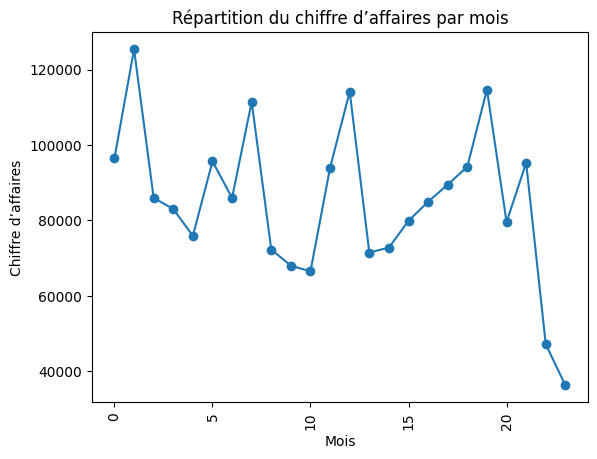

In [160]:
ca_mensuel["ca_mensuel"].plot(kind='line',marker = 'o')
plt.title("Répartition du chiffre d’affaires par mois")
plt.xlabel("Mois")
plt.ylabel("Chiffre d’affaires")
plt.xticks(rotation=90)
plt.show()

Ce graphique présente l’évolution du chiffre d’affaires de janvier 2024 à décembre 2025. On observe de fortes variations : le chiffre d’affaires atteint un niveau élevé en février 2024 et en août 2025, tandis qu’il baisse fortement en novembre 2024 en novembre et decembre 2025.

### Calcul du panier moyen (AOV)

In [129]:
# pour calculer le panier moyen on divise le chiffre d'affaire total par le nombre total de commandes.
Panier_moyen = ca_total/df1['quantity'].count()
print(Panier_moyen)

927.2438


### Calcul Taux de remise moyen (global et par catégorie)

In [130]:
# pour calculer le taux de remise moyen global, on calcule la moyenne de la colonne discount_pct dans le dataframe order_lines.
taux_de_remise_moyen_global = df1["discount_pct"].mean()
print(round(taux_de_remise_moyen_global*100,2),'%',sep='')

11.52%


Le resultat du taux de remise moyen global indique en moyenne, le pourcentage de réduction appliqueé sur toutes les commandes par l’entreprise Edumart.

In [131]:
# pour calculer le taux de remise moyen par catégorie de produit, on groupe les données par catégorie et on calcule la moyenne de la colonne discount_pct.  
taux_de_remise_par_categorie = df1.groupby("category")["discount_pct"].mean().reset_index()
taux_de_remise_par_categorie.rename(columns={"discount_pct": "taux_de_remise_moyen"}, inplace=True)
taux_de_remise_par_categorie

,category,taux_de_remise_moyen
0,Accessoire,0.116500
1,Cloud,0.116379
2,Cours,0.116460
3,Laptop,0.116408
4,Livre,0.113394
5,Logiciel,0.110790


Ce tableau montre que le taux de remise moyen est relativement homogène entre les différentes catégories de produits, avec des valeurs légèrement plus faibles pour les Livres et les Logiciels.

 ### Calcul Taux de retour (global, par catégorie, par canal)

In [132]:
# Le taux de retour global est calculé en faisant la moyenne de la colonne returned dans le dataframe order_lines.
taux_de_retour_global= df1["returned"].mean()
print(round(taux_de_retour_global*100,2),"%",sep="")

4.14%


4.14%, indique la proportion de produits retournés sur l’ensemble des commandes.

In [133]:
# Le taux de retour par catégorie est calculé en groupant les données par catégorie et en faisant la moyenne de la colonne returned.
taux_de_retour_par_categorie = df1.groupby("category")["returned"].mean().reset_index()
taux_de_retour_par_categorie.rename(columns={"returned": "taux_de_retour"}, inplace=True)
taux_de_retour_par_categorie

,category,taux_de_retour
0,Accessoire,0.066667
1,Cloud,0.034483
2,Cours,0.040288
3,Laptop,0.043689
4,Livre,0.033333
5,Logiciel,0.034364


On constate que les accessoires enregistrent un taux de retour le plus élevé (6.67%),alors que les autres catégories restent relativement faible.

### Calcul du score d’avis moyen (global, par catégorie, par délai de livraison)

In [134]:
# le score d'avis moyen global est calculé en faisant la moyenne de la colonne review_score dans le dataframe order_lines.
score_avis_moyen_global = df1["review_score"].mean()
print(round(score_avis_moyen_global,2))

4.34


Le score d’avis moyen global est de 4,34 sur 5, ce qui montre que les clients sont globalement satisfaits des produits et services d’Edumart.

In [135]:
# le score d'avis moyen par catégorie est calculé en groupant les données par catégorie et en faisant la moyenne de la colonne review_score.   
score_avis_moyen_par_categorie = df1.groupby("category")["review_score"].mean().reset_index()
score_avis_moyen_par_categorie.rename(columns={"review_score": "score_avis_moyen"}, inplace=True)
score_avis_moyen_par_categorie

,category,score_avis_moyen
0,Accessoire,4.408333
1,Cloud,4.271552
2,Cours,4.361151
3,Laptop,4.315534
4,Livre,4.309091
5,Logiciel,4.340206


Le score d’avis moyen par catégorie montre que les Accessoires sont les mieux notés par les clients (4,41), tandis que la catégorie Cloud obtient la note la plus faible (4,27). Globalement, toutes les catégories présentent un niveau de satisfaction élevé et homogène, ce qui reflète une perception positive des produits par les clients d’Edumart.

In [136]:
# pour calculer le score d'avis moyen par délai de livraison, on groupe les données par délai de livraison et on calcule la moyenne de la colonne review_score.
score_avis_moyen_par_delai_de_livraison = (
    df1.groupby("delivery_days")["review_score"]
       .mean()
       .reset_index()
       .rename(columns={"review_score": "score_avis_moyen"})
       .sort_values(by="score_avis_moyen",ascending=False)
)
score_avis_moyen_par_delai_de_livraison


,delivery_days,score_avis_moyen
20,21.0,4.500000
19,19.0,4.500000
7,7.0,4.476923
14,14.0,4.462963
5,5.0,4.435294
3,3.0,4.389558
13,13.0,4.372093
2,2.0,4.349296
9,9.0,4.340909
16,16.0,4.333333


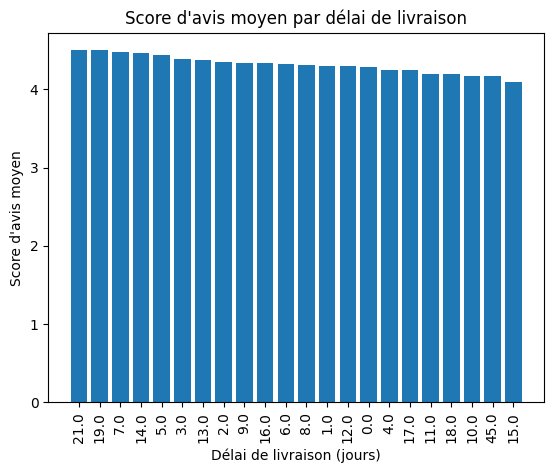

In [137]:
#
plt.bar(
    score_avis_moyen_par_delai_de_livraison["delivery_days"].astype(str), 
    score_avis_moyen_par_delai_de_livraison["score_avis_moyen"],
)
plt.title("Score d'avis moyen par délai de livraison")
plt.xlabel("Délai de livraison (jours)")
plt.ylabel("Score d'avis moyen")
plt.xticks(rotation=90)
plt.show()

L’analyse du score d’avis moyen en fonction du délai de livraison montre que les clients sont globalement très satisfaits (score >4,1). La satisfaction est maximale pour des délais de livraison relativement longs, comme 19 ou 21 jours (score 4,50), légèrement plus faible pour les délais très courts (0 à 4 jours, 4,25; 4,30) et diminue davantage notamment pour les delais 45 jours (4,17) et 15 jours (4,10). 

Etape 4 — Jointures (Merge) pour enrichir les ventes
Objectif : afin de produire une table d’analyse unique et de recalculer quelques ICP “propres”.

1. On a deja charger les 3 fichiers

2. Verfication des cles
on note que: 

- customer_id doit exister dans orders et customers
- product_id doit exister dans orders et products

In [138]:
customers.head()

,customer_id,age,gender,city,segment,signup_date
0,C0001,28.0,M,Gonaïves,Entreprise,2025-09-26
1,C0002,16.0,M,Gonaïves,Professionnel,2024-01-19
3,C0004,46.0,F,Port-au-Prince,Professionnel,2024-11-16
4,C0005,19.0,M,Cap-Haïtien,Professionnel,2024-11-21
5,C0006,20.0,M,Port-au-Prince,Entreprise,2023-11-04


In [139]:
#
order_lines[["customer_id", "order_id", "product_id"]]

,customer_id,order_id,product_id
0,C0201,O00001,P031
1,C0141,O00002,P041
2,C0025,O00003,P005
3,C0188,O00004,P042
4,C0023,O00005,P052
...,...,...,...
2195,C0378,O02196,P004
2196,C0046,O02197,P047
2197,C0126,O02198,P002
2198,C0303,O02199,P026


In [140]:
#
products.head()

,product_id,category,brand,product_name,unit_price
0,P001,Laptop,HP,Ultrabook 14,1681.08
1,P002,Laptop,ASUS,Notebook 15,1058.14
2,P003,Livre,Manning,Data Engineering,40.16
3,P004,Accessoire,Anker,SSD externe,91.27
4,P005,Laptop,HP,Gaming 16,1123.49


On remarque ci dessus que la cle customers id est presente dans customers. orders contient les cles customers_id, product_id et order_id. Products contient la cle product_id

 3. Faire les jointures
 
 - A noter que l'on doit utiliser how="left" à partir de order_lines pour ne pas perdre de ventes.

In [141]:
order_customers = pd.merge(order_lines, customers, on="customer_id", how="left", suffixes=('_ord', '_cust'))
print(order_customers.head())
# la reference du code suffixes provient de Datacamp : document du cours joindre des donnees avec Pandas

  order_id customer_id product_id order_date  quantity  unit_price  \
0   O00001       C0201       P031 2024-06-16         4      165.54   
1   O00002       C0141       P041 2024-06-10         5       46.48   
2   O00003       C0025       P005 2024-08-29         2     1123.49   
3   O00004       C0188       P042 2024-01-27         2       68.31   
4   O00005       C0023       P052 2025-08-06         3     1932.53   

   discount_pct  gross_amount  net_amount payment_method  ... review_score  \
0          0.18        662.16      542.97          Carte  ...          5.0   
1          0.14        232.40      199.86          Carte  ...          4.0   
2          0.04       2246.98     2157.10       Virement  ...          4.0   
3          0.22        136.62      106.56          Carte  ...          4.0   
4          0.17       5797.59     4812.00          Carte  ...          5.0   

     segment_ord        city_ord  category    month   age gender  \
0    Indépendant  Port-au-Prince     Cours

In [142]:
# on exporte le fichier order_customers apres jointure pour analyse future
#order_customers.to_csv("C:/Users/hp/Documents/Mini_Projet_Pandas/data/processed/order_customers.csv", index=False, encoding="utf-8")

In [143]:
# on  fait une jointure entre les tables order_lines et products sur la colonne product_id
order_products = pd.merge(order_lines, products, on="product_id", how="left", suffixes=('_ord', '_prod'))
print(order_products.head())


  order_id customer_id product_id order_date  quantity  unit_price_ord  \
0   O00001       C0201       P031 2024-06-16         4          165.54   
1   O00002       C0141       P041 2024-06-10         5           46.48   
2   O00003       C0025       P005 2024-08-29         2         1123.49   
3   O00004       C0188       P042 2024-01-27         2           68.31   
4   O00005       C0023       P052 2025-08-06         3         1932.53   

   discount_pct  gross_amount  net_amount payment_method  ... returned  \
0          0.18        662.16      542.97          Carte  ...        0   
1          0.14        232.40      199.86          Carte  ...        0   
2          0.04       2246.98     2157.10       Virement  ...        0   
3          0.22        136.62      106.56          Carte  ...        0   
4          0.17       5797.59     4812.00          Carte  ...        0   

  review_score        segment            city  category_ord    month  \
0          5.0    Indépendant  Port-au

In [144]:
# on exporte le fichier order_products apres jointure pour analyse future
#order_products.to_csv("C:/Users/hp/Documents/Mini_Projet_Pandas/data/processed/order_products.csv", index=False, encoding="utf-8")

 Contrôler la qualité de la jointure
 -  Vérification de la taille avant/après merge (nombre de lignes)

In [145]:
#
print("Avant la jointure on a: ", len(order_lines))
print("Après la jointure sur les clients on a: ", len(order_customers))
print("Après la jointure sur les produits on a: ", len(order_products))
print("\non fait une petite exploration des deux nouvelles tables:")
print("Sans jointure:", order_lines.shape)
print("jointure sur la table customers:", order_customers.shape)
print("jointure sur la table products:", order_products.shape)

Avant la jointure on a:  2200
Après la jointure sur les clients on a:  2200
Après la jointure sur les produits on a:  2200

on fait une petite exploration des deux nouvelles tables:
Sans jointure: (2200, 19)
jointure sur la table customers: (2200, 24)
jointure sur la table products: (2200, 23)


A partir des jointures qui ont ete effectuer sur l'ensemble des tables, a partir de order_lines , on remarque que les lignes restent inchangees

Tailles identiques donc pas de perte de ventes.

Comptons les lignes sans match :
- city ou segment manquant après merge (client non trouvé

In [146]:
# on verifie les valeurs des clients non trouves  dans la table order_customers 
# a noter que le symbole | signifie OU
# c'est incroyable !!! en verfiant le fichier csv qu'on a exporte, 
# on remqarque que les lignes renvoyes par python ne contiennent pas de correspondance
clients_missings = order_customers[order_customers['city_cust'].isna() | order_customers['segment_cust'].isna()]
clients_missings

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_pct,gross_amount,net_amount,payment_method,...,review_score,segment_ord,city_ord,category,month,age,gender,city_cust,segment_cust,signup_date
4,O00005,C0023,P052,2025-08-06,3,1932.53,0.17,5797.59,4812.00,Carte,...,5.0,Professionnel,Cap-Haïtien,Laptop,2025-08,NaN,NaN,NaN,NaN,NaT
30,O00031,C0342,P053,2024-05-31,2,325.90,0.07,651.80,606.17,Mobile Money,...,4.0,Étudiant,Port-au-Prince,Cloud,2024-05,NaN,NaN,NaN,NaN,NaT
59,O00060,C0433,P058,2025-09-15,4,222.36,0.25,889.44,667.08,Carte,...,4.0,Étudiant,Jérémie,Cloud,2025-09,NaN,NaN,NaN,NaN,NaT
67,O00068,C0019,P009,2024-09-14,3,157.91,0.12,473.73,416.88,Carte,...,4.0,Étudiant,Saint-Marc,Cours,2024-09,NaN,NaN,NaN,NaN,NaT
73,O00074,C0023,P049,2025-12-12,3,308.72,0.10,926.16,833.54,Mobile Money,...,4.0,Professionnel,Cap-Haïtien,Logiciel,2025-12,NaN,NaN,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2139,O02140,C0165,P011,2024-07-20,1,41.85,0.02,41.85,41.01,Carte,...,5.0,Étudiant,Port-au-Prince,Cours,2024-07,NaN,NaN,NaN,NaN,NaT
2143,O02144,C0342,P024,2024-07-19,2,133.87,0.00,267.74,267.74,Mobile Money,...,4.0,Étudiant,Port-au-Prince,Cours,2024-07,NaN,NaN,NaN,NaN,NaT
2152,O02153,C0244,P056,2025-03-21,3,144.68,0.04,434.04,416.68,Cash,...,4.0,Professionnel,Port-au-Prince,Logiciel,2025-03,NaN,NaN,NaN,NaN,NaT
2170,O02171,C0342,P013,2024-12-11,4,61.14,0.06,244.56,229.89,Carte,...,4.0,Étudiant,Port-au-Prince,Livre,2024-12,NaN,NaN,NaN,NaN,NaT


In [147]:

print("Nombre de ventes avec client manquant:", len(clients_missings))

Nombre de ventes avec client manquant: 159


- category ou unit_price manquant après merge (produit non trouvé)

In [148]:
products_missings = order_products[order_products['category_prod'].isna() | order_products['unit_price_prod'].isna()]
products_missings

,order_id,customer_id,product_id,order_date,quantity,unit_price_ord,discount_pct,gross_amount,net_amount,payment_method,...,returned,review_score,segment,city,category_ord,month,category_prod,brand,product_name,unit_price_prod


In [149]:
print("Pour la deuxieme table fusionnee avec Products. \nLe Nombre de ventes avec produit manquant:", len(products_missings))

print("\nCe qui est claire, qu'il n'y a pas de produits non trouves dans la table des produits.")

Pour la deuxieme table fusionnee avec Products. 
Le Nombre de ventes avec produit manquant: 0

Ce qui est claire, qu'il n'y a pas de produits non trouves dans la table des produits.


2. Recalculer des colonnes business après enrichissement

- À partir des colonnes produits et commandes :

In [ ]:

gross_amount_calc = order_products['unit_price_prod'] * order_products['quantity']
gross_amount_calc

0        662.16
1        232.40
2       2246.98
3        136.62
4       5797.59
         ...   
2195     182.54
2196     245.80
2197    3174.42
2198      95.37
2199     200.80
Length: 2200, dtype: float64

In [151]:
#
order_products['discount_pct'].dtypes

dtype('float64')

In [152]:
#
net_amount_calc = gross_amount_calc * (1 - order_products['discount_pct'])
net_amount_calc

0        542.9712
1        199.8640
2       2157.1008
3        106.5636
4       4811.9997
          ...    
2195     173.4130
2196     216.3040
2197    2666.5128
2198      84.8793
2199     192.7680
Length: 2200, dtype: float64

Comparer avec gross_amount et net_amount existants :
- Créer une colonne amount_diff = net_amount - net_amount_calc

In [153]:
# on fait une premiere comparaison entre le gross_amount calcule et celui present dans la table order_products
gross_amount_diff = order_products['gross_amount'] - gross_amount_calc
gross_amount_diff

0       0.000000e+00
1       2.842171e-14
2       0.000000e+00
3       0.000000e+00
4       0.000000e+00
            ...     
2195    0.000000e+00
2196    0.000000e+00
2197    0.000000e+00
2198    0.000000e+00
2199    2.842171e-14
Length: 2200, dtype: float64

In [154]:
lignes_suspectes_g = abs(gross_amount_diff) > 0.01
print("Nombre de lignes suspectes:", lignes_suspectes_g.sum()) 

Nombre de lignes suspectes: 6


In [155]:
# on fait une deuxieme comparaison entre le net_amount calcule et celui present dans la table order_products
# on cree la nouvelle colonne amount_diff dans la table order_products
order_products['amount_diff'] = order_products['net_amount'] - net_amount_calc
order_products['amount_diff']

0      -0.0012
1      -0.0040
2      -0.0008
3      -0.0036
4       0.0003
         ...  
2195   -0.0030
2196   -0.0040
2197   -0.0028
2198    0.0007
2199    0.0020
Name: amount_diff, Length: 2200, dtype: float64

Identifier les lignes “suspectes” (ex : abs(amount_diff) > 0.01)

In [156]:
# on fait l'identification des lignes suspectes
lignes_suspectes = abs(order_products['amount_diff']) > 0.01
print("Nombre de lignes suspectes:", lignes_suspectes.sum()) 

Nombre de lignes suspectes: 6


In [157]:
#changement des colonnes gross_amount et net_amount avec les valeurs calculees
order_products['gross_amount'] = gross_amount_calc
order_products['net_amount'] = net_amount_calc
order_products.rename(columns={"gross_amount": "gross_amount_calc", "net_amount": "net_amount_calc"}, inplace=True)
order_products.sort_values(by="net_amount_calc",ascending=False).head()

,order_id,customer_id,product_id,order_date,quantity,unit_price_ord,discount_pct,gross_amount_calc,net_amount_calc,payment_method,...,review_score,segment,city,category_ord,month,category_prod,brand,product_name,unit_price_prod,amount_diff
1720,O01721,C0370,P052,2024-04-22,5,1932.53,0.05,9662.65,9179.5175,Mobile Money,...,5.0,Indépendant,Montréal,Laptop,2024-04,Laptop,HP,Ultrabook 14,1932.53,0.0025
390,O00391,C0128,P052,2025-08-07,5,1932.53,0.07,9662.65,8986.2645,Virement,...,4.0,Étudiant,Saint-Marc,Laptop,2025-08,Laptop,HP,Ultrabook 14,1932.53,-0.0045
761,O00762,C0358,P052,2025-01-09,5,1932.53,0.09,9662.65,8793.0115,Carte,...,5.0,Étudiant,Port-au-Prince,Laptop,2025-01,Laptop,HP,Ultrabook 14,1932.53,-0.0015
1135,O01136,C0022,P052,2024-05-27,5,1932.53,0.11,9662.65,8599.7585,Carte,...,4.0,Étudiant,Saint-Marc,Laptop,2024-05,Laptop,HP,Ultrabook 14,1932.53,0.0015
491,O00492,C0211,P055,2024-04-24,5,1771.15,0.05,8855.75,8412.9625,Carte,...,5.0,Professionnel,Port-au-Prince,Laptop,2024-04,Laptop,Lenovo,Notebook 15,1771.15,-0.0025


Mini-analyse (après jointure)

- On produit un tableau (DataFrame) : CA net par segment client et par catégorie produit, trié décroissant.
- Ligne = segment
- colonnes = category
- valeurs = somme de net_amount_calc

In [158]:
df2 = pd.pivot_table(order_products, values = "net_amount_calc", 
                     index = "segment",
                     columns="category_prod",
                     aggfunc ="sum")
df2["CA_net"] = df2.sum(axis = 1)
df2 = df2.sort_values(by="CA_net", ascending=False)

Livrable

In [161]:
# Exportation de la table finale après merge + colonnes recalculées)
#order_products.to_csv("C:/Users/hp/Documents/Mini_Projet_Pandas/data/processed/orders_enriched.csv", index=False, encoding="utf-8")

In [ ]:
# tableau pivot : CA par segment × catégorie
df2 

category_prod,Accessoire,Cloud,Cours,Laptop,Livre,Logiciel,CA_net
segment,,,,,,,
Étudiant,16269.2221,49248.8280,78481.4354,563526.4924,13493.3560,52649.3407,773668.6746
Professionnel,18279.2875,56899.3297,69387.1389,508081.5467,15235.3036,58983.6432,726866.2496
Indépendant,8542.3893,23821.7599,36330.7431,195064.8312,7845.7545,31424.5928,303030.0708
Entreprise,7435.8515,25003.1734,20358.5071,144334.9270,4128.0328,20502.7439,221763.2357


## Rapport d’audit des données : analyse des jointures

- Vérification des clients non trouvés dans la table order_customers : certaines informations manquent.  
- Nombre de ventes associées à des clients manquants : 159.  
- Contrôle des écarts sur le montant brut (gross_amount) a identifié 6 lignes suspectes.  
- Certaines clés primaires apparaissent dans d’autres colonnes similaires, ce qui peut créer des doublons ou des ambiguïtés.  
- Des suffixes ont été ajoutés pour identifier clairement à quelles données appartiennent ces lignes, facilitant le suivi et la correction.